In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt

from sca_module.readers import create_dataset
from sca_module.simulate_L2 import GMF_SWB
from sca_module.dopsca_setup import DopSCAConfig
from sca_module.simulate_L1 import compute_beam_pattern, compute_cube_observation_geometry, compute_true_observations, create_observation_cube, compute_lpf_cube, add_L1_uncertainties
from leakage.uncertainties import band_limited_noise
from leakage.conversions import dop2vel, angular_difference, dir_from_u_v, magnitude_from_u_v, convert_to_0_360

func_rmse = lambda x, rounding=3:  np.round(np.sqrt(np.nanmean(x**2)), rounding)

plt.rcParams.update({'font.size': 10, 'font.weight' : 'bold'})

In this notebook we repeat the retrieval uncertainty estimation but then for two additional SWB runs, both over the same extent of the Mediterranean. 

The input data is cropped so as to avoid regions where the SWB fails (regions with NaN for sigma0 values). 

Then, we perform the retrieval 50 times for each case study, so that we can assess the distribution of uncertainties originating from the varibility in noise. 

The uncertainties are summarized in the table per case study.

# General preparation

Define SWB file locations

In [ ]:
files_med_1 = [
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_input_med_orb70_2022-01-20T18.nc',
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_output_med_orb70_2022-01-20T18.nc'
]

files_med_2 = [
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_input_med_orb70_2022-01-22T18.nc',
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_output_med_orb70_2022-01-22T18.nc'
]

files_cali = [
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_input_California.nc',
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_output_California.nc'
]

Loading LUTS

In [15]:
lut_dop = xr.open_dataset('/Users/opodriscoll/Documents/Scripts/DopSCA/data/dopsca/LUTs/dop_lut_20250213_companion350km.nc')['dop_S1_V']
lut_nrcs = xr.open_dataset('/Users/opodriscoll/Documents/Scripts/DopSCA/data/dopsca/LUTs/nrcs_lut_20250213_companion350km.nc')['nrcs_S1_V']

gmf = GMF_SWB(
    LUT_Doppler=lut_dop,
    LUT_nrcs=lut_nrcs,
)

Fix domain extent

In [16]:
domain = dict(grg = slice(590E3, 742E3), az = slice(50E3, 350E3)) # here we crop to keep only that part of the extend without NaN gaps

# MED case study 1

In [17]:

vars_2_save = []

for random_state in tqdm(range(50)):
    try:
        sca = DopSCAConfig()
        
        ###############################
        sca.random_state = random_state
        ###############################

        sca.Lambda = sca.get_wavelength()
        # The magic_divider is an unnecessary, but convenient, method to resample the input data to some common sampling. 
        # The data is loaded with a grid spacing of 1000 m , and the stride during pulses is 1700 m
        # Thus, a divider of 2 will interpolate the data to 850 m grid cells
        # This prevents aliasing in azimuth, and does not remove range resolution
        sca.grid_spacing_target = sca.get_grid_spacing_target(magic_divider=2)

        simulation = xr.open_mfdataset(files_med_1, compat='no_conflicts', engine='netcdf4').sel(sat = 'S1').drop_vars('bist_ang').compute()
        sca.magic_offset = sca.get_magic_offset(incidence_min=simulation.inc.min().data)

        # clipping unreasonable incidence angles
        simulation = simulation.sel(grg = slice(sca.grg_min - sca.magic_offset, sca.grg_max - sca.magic_offset))
        simulation = simulation.assign_coords(grg = simulation.grg + sca.magic_offset)

        # Here we interpolate to finer grid spacing, 
        new_az = np.arange(simulation.az.min(), simulation.az.max(), sca.grid_spacing_target)
        new_grg = np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_target)
        simulation = simulation.interp(az=new_az, grg=new_grg)
        simulation = simulation.sel(domain)

        nrcs = simulation[sca.var_nrcs].sel(pol='M')
        dop = simulation[sca.var_dop].sel(pol='M')
        inc_2d = np.degrees(simulation[sca.var_inc].expand_dims(dim={sca.dim_az: simulation.az.data}))

        data = create_dataset(
            nrcs=nrcs.data,
            dop=dop.data,
            inc=inc_2d.data,
            grg=simulation.grg.data,
            az=simulation.az.data,
            grid_spacing=sca.grid_spacing_target,
        )

        data_cube = create_observation_cube(data, sca.az_footprint_cutoff, sca.grid_spacing_target, sca.vx_sat, sca.PRF, dropna=False).compute() 
        data_cube = compute_cube_observation_geometry(data_cube, sca.dim_az_beam, sca.dim_az_slow_time, sca.dim_range, sca.var_inc, sca.z0, sca.boresight_elevation_angle_scat)

        data_cube = data_cube.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        beam = compute_beam_pattern(
            az_angle_wrt_boresight=data_cube.az_angle_wrt_boresight,
            grg_angle_wrt_boresight=data_cube.grg_angle_wrt_boresight,
            antenna_elements=sca.antenna_elements,
            antenna_weighting=sca.antenna_weighting,
            antenna_length=sca.antenna_length,
            antenna_height=sca.antenna_height,
            f0=sca.f0,
            beam_pattern=sca.beam_pattern,
        )

        data_cube['beam'] = ([sca.dim_az_beam, sca.dim_range], beam)

        data_cube = compute_true_observations(data_cube, sca.var_nrcs, sca.var_inc, sca.dim_az_beam, sca.vx_sat, sca.Lambda, var_azimuth_angle_wrt_boresight = "az_angle_wrt_boresight")
        data_cube = data_cube.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        ds = add_L1_uncertainties(
        ds = data_cube,
        dim_range = sca.dim_range,
        dim_az_beam = sca.dim_az_beam,
        vx_sat = sca.vx_sat,
        U = sca.U,
        sat_height = sca.z0,
        T_pp= sca.T_pp,
        Lambda = sca.Lambda,
        fixed_SCR=None, # < -------- here we let the SCR be calculated from the NRCS data 
        grid_spacing_slant_range=sca.grid_spacing_slant_range_SCA,
        random_state=sca.random_state
        )

        # -- Resample to uniform ground-range spacing
        ds = ds.interp(
                grg=np.arange(
                    simulation.grg.min(), 
                    simulation.grg.max(), 
                    sca.grid_spacing_slant_range_SCA
                ) , 
                method=sca.interpolator
            ).astype("float32")
        ds = ds.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        data['nrcs_scat_speckle'] = ([*data['nrcs'].dims], ds['nrcs_scat_speckle'].interp({"az_slow_time":data.az.data, "grg":data.grg.data}).data)
        mask = data["nrcs_scat_speckle"].notnull()
        data_clean = data#.where(mask, drop=True) # < -- we keep all data points, even those with no valid NRCS, to see how the retrieval performs in these cases

        data_cube_ = create_observation_cube(data_clean, sca.az_footprint_cutoff, sca.grid_spacing_target, sca.vx_sat, sca.PRF, dropna=False).compute()
        data_cube_ = compute_cube_observation_geometry(data_cube_, sca.dim_az_beam, sca.dim_az_slow_time, sca.dim_range, sca.var_inc, sca.z0, sca.boresight_elevation_angle_scat)

        data_cube_ = data_cube_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        beam = compute_beam_pattern(
            az_angle_wrt_boresight=data_cube_.az_angle_wrt_boresight,
            grg_angle_wrt_boresight=data_cube_.grg_angle_wrt_boresight,
            antenna_elements=sca.antenna_elements,
            antenna_weighting=sca.antenna_weighting,
            antenna_length=sca.antenna_length,
            antenna_height=sca.antenna_height,
            f0=sca.f0,
            beam_pattern=sca.beam_pattern,
        )

        data_cube_['beam'] = ([sca.dim_az_beam, sca.dim_range], beam)

        # here we use 'nrcs_scat_speckle' as the input NRCS, rather than the noise-free version
        data_cube_ = compute_true_observations(data_cube_, 'nrcs_scat_speckle', sca.var_inc, sca.dim_az_beam, sca.vx_sat, sca.Lambda, var_azimuth_angle_wrt_boresight = "az_angle_wrt_boresight")
        data_cube_ = data_cube_.interp(grg=np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_slant_range_SCA), method=sca.interpolator).astype("float32")
        data_cube_ = data_cube_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        mask_2 = data_cube_["V_leakage_pulse_rg"].notnull()
        ds_filt = data_cube_.where(mask_2, drop=True)

        ds['V_leakage_pulse_rg_net'] = - ds_filt['V_leakage_pulse_rg'] + ds['V_leakage_pulse_rg']
        ds['V_sigma_net'] = ds['V_leakage_pulse_rg_net'] + ds['V_pp']

        assert len(set(np.diff(data_cube_.grg))) == 1, "ground range sampling is not continuous"

        ds = compute_lpf_cube(
                ds,
                resolution_product= sca.resolution_product,
                fs_x=1 / ds.attrs["stride"],
                fs_y=1 / np.diff(data_cube_.grg)[0],
                data_2_lpf=["V_leakage_pulse_rg_net", "V_leakage_pulse_rg", "V_sigma_net", "V_sigma", "V_pp"],
                window=sca.product_averaging_window,
                crop_edges = True
            )

        assert len(set(np.diff(simulation['az']))) == 1, f"Azimuth grid is not uniformly spaced."
        spacing_simulation_az = np.diff(simulation['az'])[0]
        assert len(set(np.diff(simulation['grg']))) == 1, f"Ground range grid is not uniformly spaced."
        spacing_simulation_grg = np.diff(simulation['grg'])[0]
            
        fs_y_simulation, fs_x_simulation = 1 / spacing_simulation_az, 1 / spacing_simulation_grg

        data_2_lpf : list[str] = [
                    "wnd_u",
                    "wnd_v",
                    "wave_dop",
                    "tsc_dop"
                ]

        names_lpf_vars = [i+'_lpf' for i in data_2_lpf]

        coords_to_drop = (set(simulation.coords) - set(list(simulation[data_2_lpf[0]].dims)))

        simulation[names_lpf_vars] = compute_lpf_cube(
            ds_cube = simulation.sel(
                pol = 'M'
                ).drop_vars(
                    coords_to_drop
                )[data_2_lpf], 
            fs_y = fs_y_simulation, 
            fs_x = fs_x_simulation, 
            resolution_product = sca.resolution_product, 
            data_2_lpf = data_2_lpf,
            crop_edges = True
        )[names_lpf_vars]

        vector_uncertainty = 1 / np.sqrt(4)

        noise_u = band_limited_noise(
            da=simulation['wnd_u'],
            dims = ['az', 'grg'],
            uncertainty_resolution = sca.resolution_product,
            random_state = sca.random_state + 3
        )

        noise_v = band_limited_noise(
            da=simulation['wnd_u'],
            dims = ['az', 'grg'],
            uncertainty_resolution = sca.resolution_product,
            random_state = sca.random_state + 4
        )

        shape_ref = simulation['wnd_u'].shape

        # some re-normalization
        noise_v =  vector_uncertainty * noise_v.real / np.std(noise_v.real)
        noise_u =  vector_uncertainty * noise_u.real / np.std(noise_u.real)

        # since iid noise, we can clip time domain to correct dimensions without affecting statistics
        noise_v = noise_v[: shape_ref[0], : shape_ref[1]]
        noise_u = noise_u[: shape_ref[0], : shape_ref[1]]

        simulation['wspd_noisy']= magnitude_from_u_v(
            u=simulation['wnd_u_lpf'] + noise_u.to_numpy(),
            v=simulation['wnd_v_lpf'] + noise_v.to_numpy(),
        )

        simulation['wdir_noisy'] = dir_from_u_v(
            u=simulation['wnd_u_lpf'] + noise_u.to_numpy(),
            v=simulation['wnd_v_lpf'] + noise_v.to_numpy(),
        )

        model_wdir_deg = np.rad2deg(simulation['wdir_noisy']) 
        sensor_dir = 90 # assuming right looking

        simulation['wdir_wrt_sensor_noisy'] = convert_to_0_360(angular_difference(sensor_dir, model_wdir_deg))

        gmf_ww_Dop_noisy = gmf.Dop_forward(
            v = simulation['wspd_noisy'].to_numpy(),
            phi=simulation['wdir_wrt_sensor_noisy'].to_numpy(),
            theta=np.rad2deg(simulation['inc']).to_numpy()[None, :] * np.ones_like(simulation['wdir_wrt_sensor_noisy']),
            inverse_wave_age=1
        )

        simulation['gmf_ww_Dop_noisy'] = (['az', 'grg'], gmf_ww_Dop_noisy)

        simulation['wave_dop_residual_noisy'] = simulation['gmf_ww_Dop_noisy'] - simulation['wave_dop_lpf']

        simulation['wave_dop_residual_velocity_noisy'] = dop2vel(
            Doppler=simulation['wave_dop_residual_noisy'],
            Lambda=sca.Lambda,
            angle_incidence=np.rad2deg(simulation['inc'].to_numpy()),
            angle_azimuth=90,
            degrees=True
        )

        total_uncertainty = simulation['wave_dop_residual_velocity_noisy'].interp({"az":ds["az_slow_time"], "grg":ds["grg"]}) + ds['V_sigma_net_lpf']

        var_2_save = [
            [func_rmse(ds[i]) for i in ds[["V_pp", "V_leakage_pulse_rg", "V_leakage_pulse_rg_net", "V_sigma", "V_sigma_net", "V_pp_lpf", "V_leakage_pulse_rg_lpf", "V_leakage_pulse_rg_net_lpf", "V_sigma_lpf", "V_sigma_net_lpf"]]] 
            + [func_rmse(simulation['wave_dop_residual_velocity_noisy'])] 
            + [func_rmse(total_uncertainty)]
        ]

        vars_2_save.append(var_2_save)

    except Exception as e:
        print(f"Error in random state {random_state}: {e}")
        continue

100%|██████████| 50/50 [09:31<00:00, 11.43s/it]


(12.529074968308183, 2.4088800676254025)

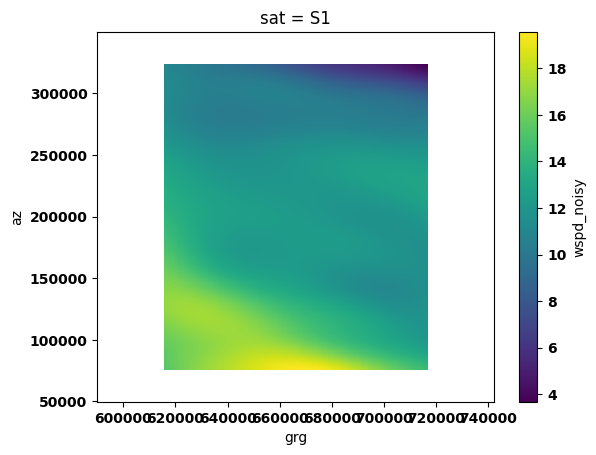

In [22]:
simulation.wspd_noisy.plot()
simulation.wspd_noisy.mean().item(), simulation.wspd_noisy.std().item()

In [23]:
columns = ["V_pp", "V_leakage_pulse_rg", "V_leakage_pulse_rg_net", "V_sigma", "V_sigma_net", "V_pp_lpf", "V_leakage_pulse_rg_lpf", "V_leakage_pulse_rg_net_lpf", "V_sigma_lpf", "V_sigma_net_lpf", "wave_dop_residual_velocity_noisy", "total_uncertainty"]
data = np.array(vars_2_save).squeeze()
pd.DataFrame(data, columns=columns).describe()

,V_pp,V_leakage_pulse_rg,V_leakage_pulse_rg_net,V_sigma,V_sigma_net,V_pp_lpf,V_leakage_pulse_rg_lpf,V_leakage_pulse_rg_net_lpf,V_sigma_lpf,V_sigma_net_lpf,wave_dop_residual_velocity_noisy,total_uncertainty
count,50.000000,50.000,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.000000,50.000000,50.000000,50.00000,50.000000
mean,73.854080,2.587,3.921060,73.899680,78.315461,1.875080,1.854000e+00,0.591140,2.648900,1.911100,0.11100,1.916300
std,0.190622,0.000,0.061197,0.188337,0.217187,0.235067,6.728968e-16,0.079947,0.300724,0.282884,0.00956,0.283816
min,73.545998,2.587,3.795000,73.598999,77.782997,1.482000,1.854000e+00,0.424000,2.111000,1.367000,0.08700,1.368000
25%,73.723251,2.587,3.873750,73.768250,78.177252,1.712000,1.854000e+00,0.543500,2.387000,1.724000,0.10425,1.717250
50%,73.839500,2.587,3.915500,73.874001,78.297001,1.874500,1.854000e+00,0.579500,2.631500,1.884500,0.11150,1.892000
75%,73.981499,2.587,3.958000,74.015997,78.492252,2.004500,1.854000e+00,0.647750,2.870000,2.112250,0.11700,2.112750
max,74.343002,2.587,4.054000,74.388000,78.870003,2.648000,1.854000e+00,0.803000,3.184000,2.799000,0.13500,2.800000


# MED case study 2

In [24]:

vars_2_save = []

for random_state in tqdm(range(50)):
    try:
        sca = DopSCAConfig()
        
        ###############################
        sca.random_state = random_state
        ###############################

        sca.Lambda = sca.get_wavelength()
        # The magic_divider is an unnecessary, but convenient, method to resample the input data to some common sampling. 
        # The data is loaded with a grid spacing of 1000 m , and the stride during pulses is 1700 m
        # Thus, a divider of 2 will interpolate the data to 850 m grid cells
        # This prevents aliasing in azimuth, and does not remove range resolution
        sca.grid_spacing_target = sca.get_grid_spacing_target(magic_divider=2)

        simulation = xr.open_mfdataset(files_med_2, compat='no_conflicts', engine='netcdf4').sel(sat = 'S1').drop_vars('bist_ang').compute()
        sca.magic_offset = sca.get_magic_offset(incidence_min=simulation.inc.min().data)

        # clipping unreasonable incidence angles
        simulation = simulation.sel(grg = slice(sca.grg_min - sca.magic_offset, sca.grg_max - sca.magic_offset))
        simulation = simulation.assign_coords(grg = simulation.grg + sca.magic_offset)

        # Here we interpolate to finer grid spacing, 
        new_az = np.arange(simulation.az.min(), simulation.az.max(), sca.grid_spacing_target)
        new_grg = np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_target)
        simulation = simulation.interp(az=new_az, grg=new_grg)
        simulation = simulation.sel(domain)

        nrcs = simulation[sca.var_nrcs].sel(pol='M')
        dop = simulation[sca.var_dop].sel(pol='M')
        inc_2d = np.degrees(simulation[sca.var_inc].expand_dims(dim={sca.dim_az: simulation.az.data}))

        data = create_dataset(
            nrcs=nrcs.data,
            dop=dop.data,
            inc=inc_2d.data,
            grg=simulation.grg.data,
            az=simulation.az.data,
            grid_spacing=sca.grid_spacing_target,
        )

        data_cube = create_observation_cube(data, sca.az_footprint_cutoff, sca.grid_spacing_target, sca.vx_sat, sca.PRF, dropna=False).compute() 
        data_cube = compute_cube_observation_geometry(data_cube, sca.dim_az_beam, sca.dim_az_slow_time, sca.dim_range, sca.var_inc, sca.z0, sca.boresight_elevation_angle_scat)

        data_cube = data_cube.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        beam = compute_beam_pattern(
            az_angle_wrt_boresight=data_cube.az_angle_wrt_boresight,
            grg_angle_wrt_boresight=data_cube.grg_angle_wrt_boresight,
            antenna_elements=sca.antenna_elements,
            antenna_weighting=sca.antenna_weighting,
            antenna_length=sca.antenna_length,
            antenna_height=sca.antenna_height,
            f0=sca.f0,
            beam_pattern=sca.beam_pattern,
        )

        data_cube['beam'] = ([sca.dim_az_beam, sca.dim_range], beam)

        data_cube = compute_true_observations(data_cube, sca.var_nrcs, sca.var_inc, sca.dim_az_beam, sca.vx_sat, sca.Lambda, var_azimuth_angle_wrt_boresight = "az_angle_wrt_boresight")
        data_cube = data_cube.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        ds = add_L1_uncertainties(
        ds = data_cube,
        dim_range = sca.dim_range,
        dim_az_beam = sca.dim_az_beam,
        vx_sat = sca.vx_sat,
        U = sca.U,
        sat_height = sca.z0,
        T_pp= sca.T_pp,
        Lambda = sca.Lambda,
        fixed_SCR=None, # < -------- here we let the SCR be calculated from the NRCS data 
        grid_spacing_slant_range=sca.grid_spacing_slant_range_SCA,
        random_state=sca.random_state
        )

        # -- Resample to uniform ground-range spacing
        ds = ds.interp(
                grg=np.arange(
                    simulation.grg.min(), 
                    simulation.grg.max(), 
                    sca.grid_spacing_slant_range_SCA
                ) , 
                method=sca.interpolator
            ).astype("float32")
        ds = ds.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        data['nrcs_scat_speckle'] = ([*data['nrcs'].dims], ds['nrcs_scat_speckle'].interp({"az_slow_time":data.az.data, "grg":data.grg.data}).data)
        mask = data["nrcs_scat_speckle"].notnull()
        data_clean = data#.where(mask, drop=True) # < -- we keep all data points, even those with no valid NRCS, to see how the retrieval performs in these cases

        data_cube_ = create_observation_cube(data_clean, sca.az_footprint_cutoff, sca.grid_spacing_target, sca.vx_sat, sca.PRF, dropna=False).compute()
        data_cube_ = compute_cube_observation_geometry(data_cube_, sca.dim_az_beam, sca.dim_az_slow_time, sca.dim_range, sca.var_inc, sca.z0, sca.boresight_elevation_angle_scat)

        data_cube_ = data_cube_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        beam = compute_beam_pattern(
            az_angle_wrt_boresight=data_cube_.az_angle_wrt_boresight,
            grg_angle_wrt_boresight=data_cube_.grg_angle_wrt_boresight,
            antenna_elements=sca.antenna_elements,
            antenna_weighting=sca.antenna_weighting,
            antenna_length=sca.antenna_length,
            antenna_height=sca.antenna_height,
            f0=sca.f0,
            beam_pattern=sca.beam_pattern,
        )

        data_cube_['beam'] = ([sca.dim_az_beam, sca.dim_range], beam)

        # here we use 'nrcs_scat_speckle' as the input NRCS, rather than the noise-free version
        data_cube_ = compute_true_observations(data_cube_, 'nrcs_scat_speckle', sca.var_inc, sca.dim_az_beam, sca.vx_sat, sca.Lambda, var_azimuth_angle_wrt_boresight = "az_angle_wrt_boresight")
        data_cube_ = data_cube_.interp(grg=np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_slant_range_SCA), method=sca.interpolator).astype("float32")
        data_cube_ = data_cube_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

        mask_2 = data_cube_["V_leakage_pulse_rg"].notnull()
        ds_filt = data_cube_.where(mask_2, drop=True)

        ds['V_leakage_pulse_rg_net'] = - ds_filt['V_leakage_pulse_rg'] + ds['V_leakage_pulse_rg']
        ds['V_sigma_net'] = ds['V_leakage_pulse_rg_net'] + ds['V_pp']

        assert len(set(np.diff(data_cube_.grg))) == 1, "ground range sampling is not continuous"

        ds = compute_lpf_cube(
                ds,
                resolution_product= sca.resolution_product,
                fs_x=1 / ds.attrs["stride"],
                fs_y=1 / np.diff(data_cube_.grg)[0],
                data_2_lpf=["V_leakage_pulse_rg_net", "V_leakage_pulse_rg", "V_sigma_net", "V_sigma", "V_pp"],
                window=sca.product_averaging_window,
                crop_edges = True
            )

        assert len(set(np.diff(simulation['az']))) == 1, f"Azimuth grid is not uniformly spaced."
        spacing_simulation_az = np.diff(simulation['az'])[0]
        assert len(set(np.diff(simulation['grg']))) == 1, f"Ground range grid is not uniformly spaced."
        spacing_simulation_grg = np.diff(simulation['grg'])[0]
            
        fs_y_simulation, fs_x_simulation = 1 / spacing_simulation_az, 1 / spacing_simulation_grg

        data_2_lpf : list[str] = [
                    "wnd_u",
                    "wnd_v",
                    "wave_dop",
                    "tsc_dop"
                ]

        names_lpf_vars = [i+'_lpf' for i in data_2_lpf]

        coords_to_drop = (set(simulation.coords) - set(list(simulation[data_2_lpf[0]].dims)))

        simulation[names_lpf_vars] = compute_lpf_cube(
            ds_cube = simulation.sel(
                pol = 'M'
                ).drop_vars(
                    coords_to_drop
                )[data_2_lpf], 
            fs_y = fs_y_simulation, 
            fs_x = fs_x_simulation, 
            resolution_product = sca.resolution_product, 
            data_2_lpf = data_2_lpf,
            crop_edges = True
        )[names_lpf_vars]

        vector_uncertainty = 1 / np.sqrt(4)

        noise_u = band_limited_noise(
            da=simulation['wnd_u'],
            dims = ['az', 'grg'],
            uncertainty_resolution = sca.resolution_product,
            random_state = sca.random_state + 3
        )

        noise_v = band_limited_noise(
            da=simulation['wnd_u'],
            dims = ['az', 'grg'],
            uncertainty_resolution = sca.resolution_product,
            random_state = sca.random_state + 4
        )

        shape_ref = simulation['wnd_u'].shape

        # some re-normalization
        noise_v =  vector_uncertainty * noise_v.real / np.std(noise_v.real)
        noise_u =  vector_uncertainty * noise_u.real / np.std(noise_u.real)

        # since iid noise, we can clip time domain to correct dimensions without affecting statistics
        noise_v = noise_v[: shape_ref[0], : shape_ref[1]]
        noise_u = noise_u[: shape_ref[0], : shape_ref[1]]

        simulation['wspd_noisy']= magnitude_from_u_v(
            u=simulation['wnd_u_lpf'] + noise_u.to_numpy(),
            v=simulation['wnd_v_lpf'] + noise_v.to_numpy(),
        )

        simulation['wdir_noisy'] = dir_from_u_v(
            u=simulation['wnd_u_lpf'] + noise_u.to_numpy(),
            v=simulation['wnd_v_lpf'] + noise_v.to_numpy(),
        )

        model_wdir_deg = np.rad2deg(simulation['wdir_noisy']) 
        sensor_dir = 90 # assuming right looking

        simulation['wdir_wrt_sensor_noisy'] = convert_to_0_360(angular_difference(sensor_dir, model_wdir_deg))

        gmf_ww_Dop_noisy = gmf.Dop_forward(
            v = simulation['wspd_noisy'].to_numpy(),
            phi=simulation['wdir_wrt_sensor_noisy'].to_numpy(),
            theta=np.rad2deg(simulation['inc']).to_numpy()[None, :] * np.ones_like(simulation['wdir_wrt_sensor_noisy']),
            inverse_wave_age=1
        )

        simulation['gmf_ww_Dop_noisy'] = (['az', 'grg'], gmf_ww_Dop_noisy)

        simulation['wave_dop_residual_noisy'] = simulation['gmf_ww_Dop_noisy'] - simulation['wave_dop_lpf']

        simulation['wave_dop_residual_velocity_noisy'] = dop2vel(
            Doppler=simulation['wave_dop_residual_noisy'],
            Lambda=sca.Lambda,
            angle_incidence=np.rad2deg(simulation['inc'].to_numpy()),
            angle_azimuth=90,
            degrees=True
        )

        total_uncertainty = simulation['wave_dop_residual_velocity_noisy'].interp({"az":ds["az_slow_time"], "grg":ds["grg"]}) + ds['V_sigma_net_lpf']

        var_2_save = [
            [func_rmse(ds[i]) for i in ds[["V_pp", "V_leakage_pulse_rg", "V_leakage_pulse_rg_net", "V_sigma", "V_sigma_net", "V_pp_lpf", "V_leakage_pulse_rg_lpf", "V_leakage_pulse_rg_net_lpf", "V_sigma_lpf", "V_sigma_net_lpf"]]] 
            + [func_rmse(simulation['wave_dop_residual_velocity_noisy'])] 
            + [func_rmse(total_uncertainty)]
        ]

        vars_2_save.append(var_2_save)

    except Exception as e:
        print(f"Error in random state {random_state}: {e}")
        continue

100%|██████████| 50/50 [09:24<00:00, 11.29s/it]


In [74]:
columns = ["V_pp", "V_leakage_pulse_rg", "V_leakage_pulse_rg_net", "V_sigma", "V_sigma_net", "V_pp_lpf", "V_leakage_pulse_rg_lpf", "V_leakage_pulse_rg_net_lpf", "V_sigma_lpf", "V_sigma_net_lpf", "wave_dop_residual_velocity_noisy", "total_uncertainty"]
data = np.array(vars_2_save).squeeze()
pd.DataFrame(data, columns=columns).describe()

,V_pp,V_leakage_pulse_rg,V_leakage_pulse_rg_net,V_sigma,V_sigma_net,V_pp_lpf,V_leakage_pulse_rg_lpf,V_leakage_pulse_rg_net_lpf,V_sigma_lpf,V_sigma_net_lpf,wave_dop_residual_velocity_noisy,total_uncertainty
count,50.000000,50.000,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.00000,50.000000,50.000000,50.000000,50.000000
mean,72.695380,1.477,3.890240,72.710020,77.034740,1.845560,1.126000e+00,0.45760,2.162540,1.843680,0.135040,1.849680
std,0.191171,0.000,0.068524,0.191749,0.219783,0.228127,6.728968e-16,0.05003,0.235879,0.273179,0.011069,0.273944
min,72.382004,1.477,3.740000,72.394997,76.482002,1.441000,1.126000e+00,0.35300,1.608000,1.286000,0.110000,1.317000
25%,72.570000,1.477,3.843500,72.589499,76.905499,1.688500,1.126000e+00,0.41875,1.994250,1.679000,0.127250,1.689750
50%,72.683502,1.477,3.882000,72.698002,77.009499,1.846000,1.126000e+00,0.46000,2.165500,1.797000,0.135000,1.822500
75%,72.817249,1.477,3.932750,72.837252,77.197998,1.968000,1.126000e+00,0.49400,2.327500,2.008000,0.143750,2.013250
max,73.169998,1.477,4.070000,73.185997,77.584999,2.591000,1.126000e+00,0.56600,2.652000,2.705000,0.162000,2.683000


## Wind speeds

### Cali

(<xarray.DataArray ()> Size: 8B
 array(9.99927338)
 Coordinates:
     sat      <U2 8B 'S1',
 <xarray.DataArray ()> Size: 8B
 array(1.64237098)
 Coordinates:
     sat      <U2 8B 'S1')

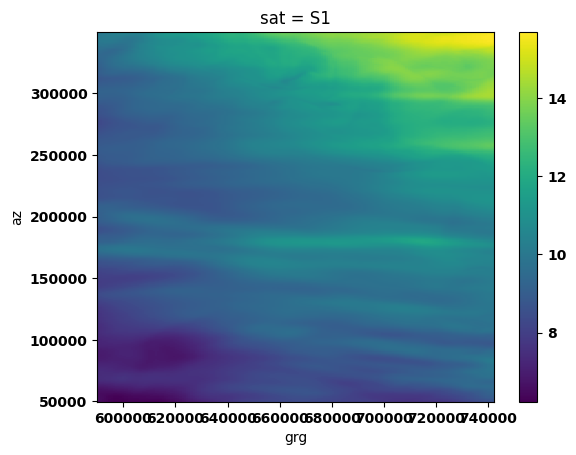

In [76]:
simulation = xr.open_mfdataset(files_cali, compat='no_conflicts', engine='netcdf4').sel(sat = 'S1').drop_vars('bist_ang').compute()
sca.magic_offset = sca.get_magic_offset(incidence_min=simulation.inc.min().data)

# clipping unreasonable incidence angles
simulation = simulation.sel(grg = slice(sca.grg_min - sca.magic_offset, sca.grg_max - sca.magic_offset))
simulation = simulation.assign_coords(grg = simulation.grg + sca.magic_offset)

# Here we interpolate to finer grid spacing, 
new_az = np.arange(simulation.az.min(), simulation.az.max(), sca.grid_spacing_target)
new_grg = np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_target)
simulation = simulation.interp(az=new_az, grg=new_grg)
simulation = simulation.sel(domain)

wspd = magnitude_from_u_v(
    u=simulation['wnd_u'],
    v=simulation['wnd_v'],
)

wspd.plot()
wspd.mean(), wspd.std(), 

### Med-2

(<xarray.DataArray ()> Size: 8B
 array(11.89939785)
 Coordinates:
     sat      <U2 8B 'S1',
 <xarray.DataArray ()> Size: 8B
 array(2.45400718)
 Coordinates:
     sat      <U2 8B 'S1')

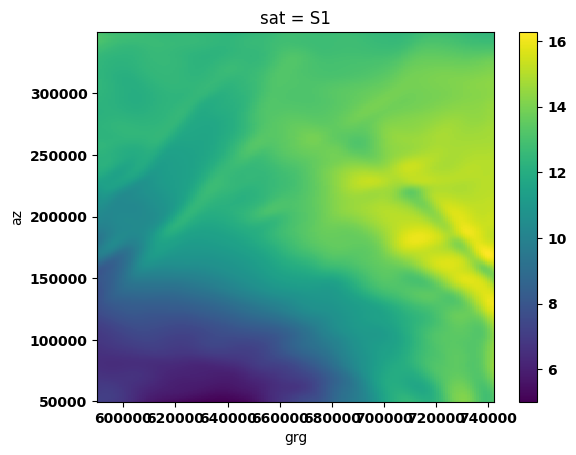

In [78]:
simulation = xr.open_mfdataset(files_med_2, compat='no_conflicts', engine='netcdf4').sel(sat = 'S1').drop_vars('bist_ang').compute()
sca.magic_offset = sca.get_magic_offset(incidence_min=simulation.inc.min().data)

# clipping unreasonable incidence angles
simulation = simulation.sel(grg = slice(sca.grg_min - sca.magic_offset, sca.grg_max - sca.magic_offset))
simulation = simulation.assign_coords(grg = simulation.grg + sca.magic_offset)

# Here we interpolate to finer grid spacing, 
new_az = np.arange(simulation.az.min(), simulation.az.max(), sca.grid_spacing_target)
new_grg = np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_target)
simulation = simulation.interp(az=new_az, grg=new_grg)
simulation = simulation.sel(domain)

wspd = magnitude_from_u_v(
    u=simulation['wnd_u'],
    v=simulation['wnd_v'],
)

wspd.plot()
wspd.mean(), wspd.std(), 

### Med-1

(<xarray.DataArray ()> Size: 8B
 array(12.4037049)
 Coordinates:
     sat      <U2 8B 'S1',
 <xarray.DataArray ()> Size: 8B
 array(3.0136295)
 Coordinates:
     sat      <U2 8B 'S1')

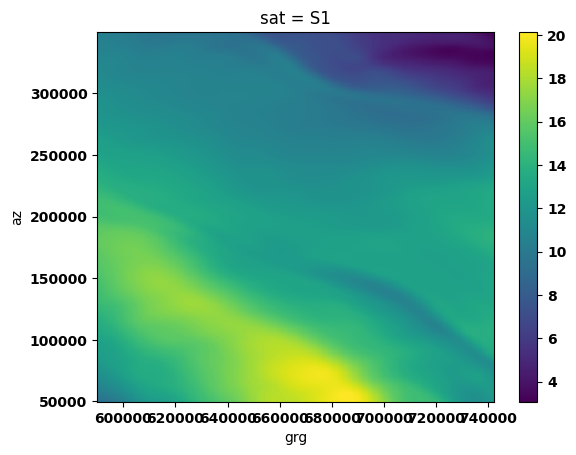

In [ ]:
simulation = xr.open_mfdataset(files_med_1, compat='no_conflicts', engine='netcdf4').sel(sat = 'S1').drop_vars('bist_ang').compute()
sca.magic_offset = sca.get_magic_offset(incidence_min=simulation.inc.min().data)

# clipping unreasonable incidence angles
simulation = simulation.sel(grg = slice(sca.grg_min - sca.magic_offset, sca.grg_max - sca.magic_offset))
simulation = simulation.assign_coords(grg = simulation.grg + sca.magic_offset)

# Here we interpolate to finer grid spacing, 
new_az = np.arange(simulation.az.min(), simulation.az.max(), sca.grid_spacing_target)
new_grg = np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_target)
simulation = simulation.interp(az=new_az, grg=new_grg)
simulation = simulation.sel(domain)

wspd = magnitude_from_u_v(
    u=simulation['wnd_u'],
    v=simulation['wnd_v'],
)

wspd.plot()
wspd.mean(), wspd.std(), 